# Milestone 2 · Detection dataset construction

This notebook builds the synthetic multi-celebrity detection dataset that Milestone 3 uses to fine-tune YOLOv8. It runs end to end, from the raw CelebA photos of our five Milestone 1 identities to a finished, augmented, YOLO-formatted dataset with train/val/test folders.

| Step | Team task | What happens here |
| --- | --- | --- |
| 0 | — | Load and verify the raw CelebA crops of the five identities |
| 1 | Split (Murat) | Assign every source photo to exactly one split **before** composing, so no face photo is shared between splits |
| 2 | Composition (Aditi) | Aditi's composition approach, extended: group-photo layouts on room backgrounds, soft masks, varied scale, position and lighting |
| 3 | Annotation (Dario) | Dario's YuNet face-detector method produces tight face boxes in YOLO format; frames with a missing or unlabelled face are regenerated |
| 4 | Augmentation (Murat) | Box-aware augmentation of the training frames only |
| 5 | Split export (Murat) | Write `train/`, `val/`, `test/` (images + labels) and `data.yaml` |
| 6 | Checks | Leakage, format and label-accuracy checks; sample annotated images |

All randomness is seeded, so running the notebook again produces byte-identical files. The code is in [`m2_dataset.py`](m2_dataset.py); the notebook calls it step by step. Running everything takes about two minutes on a laptop CPU.

In [1]:
%config InlineBackend.figure_formats = ["jpeg"]  # photo grids: keep the notebook small
import json
import platform
import sys
from collections import Counter
from pathlib import Path

import albumentations
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

M2 = Path.cwd() if (Path.cwd() / "m2_dataset.py").exists() else Path.cwd() / "project_milestone02"
sys.path.insert(0, str(M2))
import m2_dataset as M

print("Python", platform.python_version(), "| OpenCV", cv2.__version__, "| albumentations", albumentations.__version__)
print("Classes (same order as Milestone 1):", dict(enumerate(M.IDS)))
print("Seed:", M.SEED, "| frame size:", (M.W, M.H), "| composed frames:", M.BASE_FRAMES, "| augmented copies per train frame:", M.AUG_COPIES)

Python 3.13.15 | OpenCV 5.0.0 | albumentations 2.0.8
Classes (same order as Milestone 1): {0: '7007', 1: '2970', 2: '2336', 3: '7', 4: '4428'}
Seed: 47 | frame size: (800, 600) | composed frames: {'train': 168, 'val': 36, 'test': 36} | augmented copies per train frame: 2


## 0. Raw CelebA crops

The input is the fixed Milestone 1 subset in `data/identities/`: the original aligned CelebA JPEGs (178 × 218) of identities 7007, 2970, 2336, 7 and 4428. These are the identities the team committed to in Milestone 1, and the class order matches the Milestone 1 classifier.

identity,7007,2970,2336,7,4428
photos,24,25,25,24,23


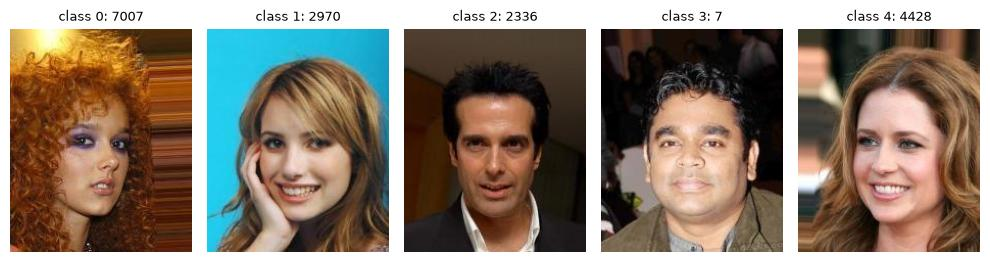

In [2]:
raw = pd.DataFrame([{"identity": i, "photos": len(list((M.DATA_DIR / i).glob("*.jpg")))} for i in M.IDS])
display(raw.set_index("identity").T)

fig, axes = plt.subplots(1, 5, figsize=(10, 2.6))
for ax, identity in zip(axes, M.IDS):
    ax.imshow(Image.open(sorted((M.DATA_DIR / identity).glob("*.jpg"))[0]))
    ax.set_title(f"class {M.IDS.index(identity)}: {identity}", fontsize=9)
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 1. Leak-free source split (decided before composing)

A synthetic frame reuses source photos, and one photo can appear in many frames. Splitting the finished frames at random would put the same face photo in both training and test frames and inflate Milestone 3's mAP. We therefore split the **source photos** first and compose each split's frames only from that split's photos.

We reuse the Milestone 1 split (per identity: 17 train, 3 val, 3 test photos). The six photos Milestone 1 left out when balancing classes are alternated between val and test. Consequences:

- No source photo, and therefore no face crop, appears in more than one split.
- Every identity appears in every split.
- Milestone 3 test faces are also unseen by the Milestone 1 classifier, so the two models can later be evaluated together without leakage.

In [3]:
sources = M.source_split()
src = pd.DataFrame(sources)
display(src.pivot_table(index="identity", columns="split", values="file", aggfunc="count").loc[M.IDS, list(M.SPLITS)])
print(src.groupby("split").file.count().to_dict(), "photos in total")

split,train,val,test
identity,,,
7007,17,4,3
2970,17,4,4
2336,17,4,4
7,17,4,3
4428,17,3,3


{'test': 17, 'train': 85, 'val': 19} photos in total


## 2. Composition

Each frame is an 800 × 600 "group photo" that contains 2–5 **different** identities (weights 25/30/25/20 %). It extends Aditi's approach of pasting celebrity crops onto a shared background, with changes aimed at plausible classroom or group photographs rather than identical templates:

| Design choice | Implementation | Why |
| --- | --- | --- |
| Room backgrounds | Procedural wall gradient, floor, whiteboards, windows, posters and doors in random colours and positions, plus soft directional light | Varied indoor scenes without licensing third-party photos |
| Group layout | One row, or two rows (back row 78–90 % the height of the front row, standing in the gaps) | Mimics classroom and team photos; adds scale variation within a frame |
| Scale | A per-frame "camera distance" factor (0.62–1.0), plus ±8 % per person; labelled faces are 55–160 px wide (median 90) | Detector must handle near and far faces |
| Natural blending | Soft elliptical head mask, a neck/shoulder/clothing silhouette under each head, and an optional desk in front | Hides the rectangular photo border; looks like people rather than pasted cards |
| Aspect ratio | Kept at the CelebA 178:218 ratio | Avoids stretched faces |
| Lighting | Per-person brightness 0.85–1.15 and tint ±4 %, plus per-frame exposure, colour cast and slight blur | Different people and rooms are lit differently |
| No face occlusion | A layout is rejected if any later-painted person covers more than 3 % of an earlier face, or if a face would leave the frame | Every labelled face is fully visible |

The frames below are composed with the same functions used for the dataset (seeded previews).

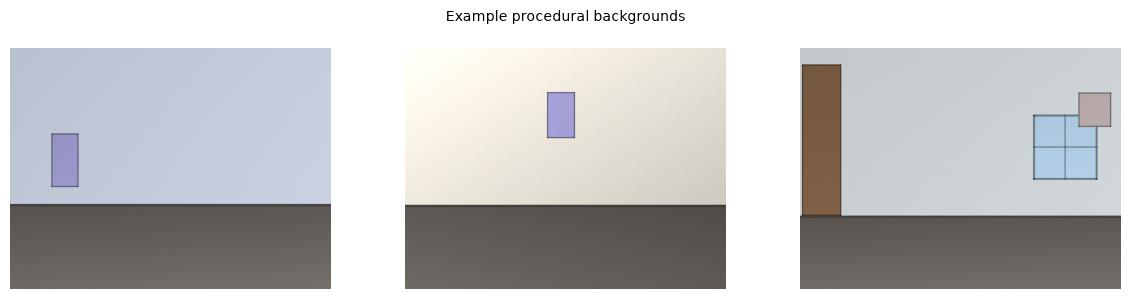

In [4]:
detector = M.load_detector()
source_faces = M.face_boxes_in_sources(detector, sources)
pools = {s: {i: [r["file"] for r in sources if r["split"] == s and r["identity"] == i] for i in M.IDS} for s in M.SPLITS}

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for k, ax in enumerate(axes):
    ax.imshow(M.make_background(np.random.default_rng([999, k])).astype(np.uint8)); ax.set_axis_off()
fig.suptitle("Example procedural backgrounds", fontsize=10); plt.tight_layout(); plt.show()

## 3. Annotation (YOLO format)

We keep Dario's annotation method: the pretrained **YuNet** face detector (OpenCV Zoo, NMS 0.30; the model file is downloaded once and checked against a pinned SHA-256). The detector only localises faces. The identity, and therefore the class id, is known from the composition record.

For every composed frame, YuNet runs on the frame exactly as it will be saved (after JPEG encoding):

1. Each placed person must match exactly one detection with confidence ≥ 0.70 and IoU ≥ 0.5 against the face position expected from that person's source photo. The **detected** box (tight around the face) becomes the label.
2. Any other face-like detection with confidence ≥ 0.50 that overlaps no labelled face (IoU < 0.3) means an unlabelled face is visible, for example a bystander at the edge of a source photo. The lower threshold also catches borderline faces.

A frame that fails either check is discarded and recomposed with a new seeded layout, so every face in the dataset is labelled and every label is a face. Each frame gets one YOLO `.txt` file with one row per face: `class_id x_center y_center width height`, normalized to the frame size.

train: 168 frames (61 layouts and 1 annotations rejected and regenerated)


val: 36 frames (11 layouts and 0 annotations rejected and regenerated)


test: 36 frames (14 layouts and 0 annotations rejected and regenerated)


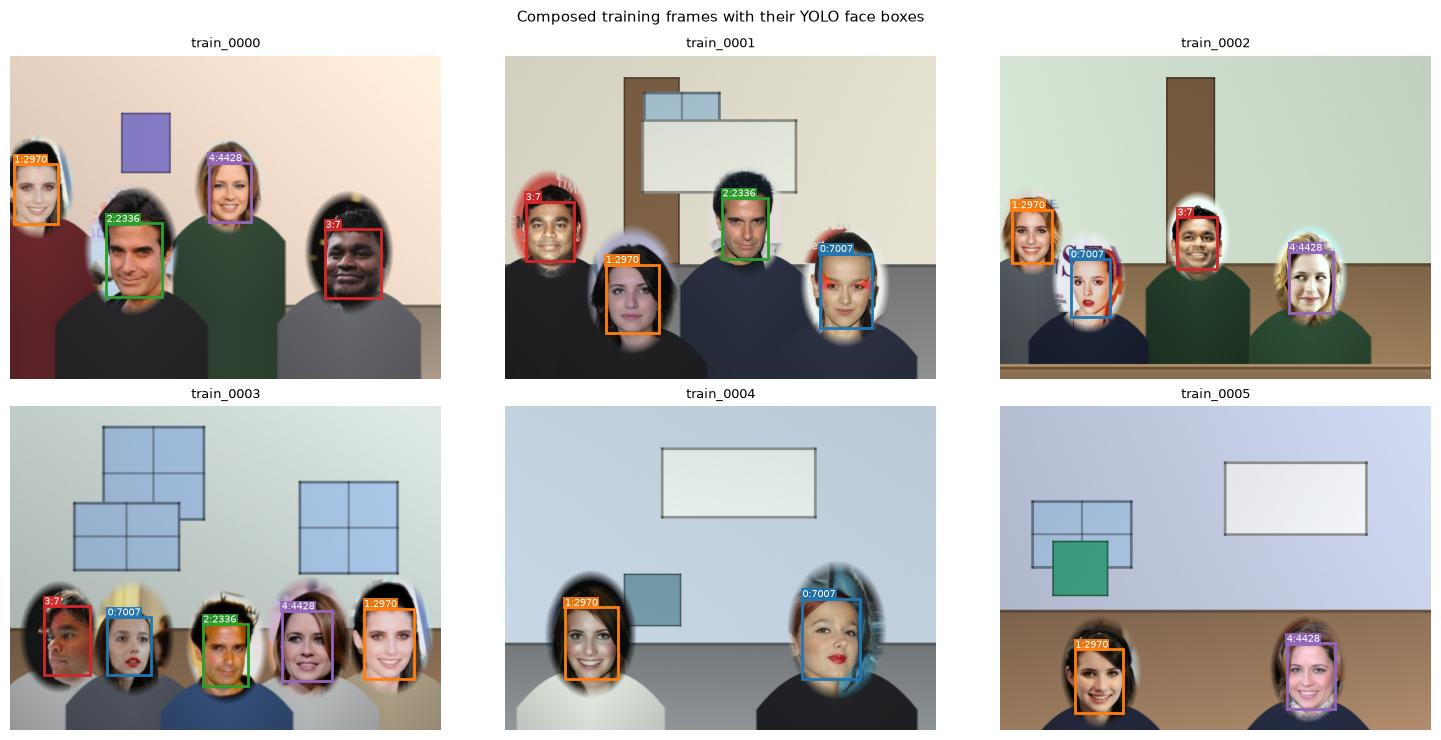

Example label file (train_0000.txt):
2 0.287897 0.632220 0.129705 0.228501
3 0.794951 0.642625 0.128621 0.212797
4 0.509449 0.422032 0.098916 0.183085
1 0.059791 0.427052 0.101704 0.184047



In [5]:
frames, attempts = {}, {}
for split in M.SPLITS:
    frames[split], attempts[split] = M.build_frames(detector, split, pools[split], source_faces, M.BASE_FRAMES[split])

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, frame in zip(axes.flat, frames["train"][:6]):
    M.draw_boxes(frame["rgb"], M.yolo_rows(frame["people"]), ax, frame["name"])
fig.suptitle("Composed training frames with their YOLO face boxes", fontsize=11); plt.tight_layout(); plt.show()
print("Example label file (train_0000.txt):")
print("".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n" for c, x, y, w, h in M.yolo_rows(frames["train"][0]["people"])))

## 4. Augmentation (training frames only)

Augmentation is applied **after** the split and **only to training frames**, so validation and test stay untouched originals. Each training frame gets 2 augmented copies (168 originals → 504 training images). Boxes are transformed together with the image ([albumentations](https://albumentations.ai/), YOLO bbox format, ellipse-based box rotation).

An augmented copy is rejected and resampled when:

- any face would lose more than 5 % of its box outside the frame (`min_visibility=0.95`), or would shrink below 29 px; this keeps every label complete;
- YuNet finds a face-like region (confidence ≥ 0.50) that is not labelled. Augmentation can make a half-visible bystander in a source photo detectable;
- the copy is practically identical to its original or to the other copy, since each transform is applied only with a given probability.

Each transform is seeded separately. With albumentations 2.0.8, a single seeded `Compose` draws the same random number for every transform, so transforms were applied all together or not at all. Separate seeds keep them independent and reproducible.

In [6]:
display(pd.DataFrame(M.AUGMENTATIONS, columns=["transform", "parameters", "why"]).style.hide(axis="index"))
print("Deliberately not used:")
display(pd.DataFrame(M.NOT_USED, columns=["transform", "why not"]).style.hide(axis="index"))

transform,parameters,why
HorizontalFlip,p=0.5,Faces are left-right symmetric and identity does not depend on side; doubles pose variety.
Affine,"scale 0.85-1.15, translate +/-5%, rotate +/-7 deg, p=0.8","Camera distance, framing and slight head/camera tilt. Small angles keep boxes tight (ellipse-based box rotation)."
RandomBrightnessContrast,"brightness +/-0.2, contrast +/-0.2, p=0.7",Indoor lighting and exposure differences.
HueSaturationValue,"hue +/-5, saturation +/-15, value +/-10, p=0.4","White balance and camera colour differences, kept small so skin tones stay plausible."
RandomGamma,"gamma 85-115, p=0.3",Non-linear exposure differences.
GaussianBlur or MotionBlur,"kernel 3-5 / 3-7, p=0.25",Slight defocus or hand shake in group photos.
GaussNoise,"std 0.01-0.04, p=0.25",Sensor noise in dim rooms.
ImageCompression,"JPEG quality 60-95, p=0.3",Compression artefacts from phones and messaging apps.


Deliberately not used:


transform,why not
Vertical flip / large rotation,Upside-down or strongly rotated faces do not occur in group photos and loosen boxes.
Cutout / random erasing,Could hide a labelled face and leave a wrong label.
Mosaic / mixup,Applied online by YOLOv8 during Milestone 3 training; doing it offline would duplicate it.


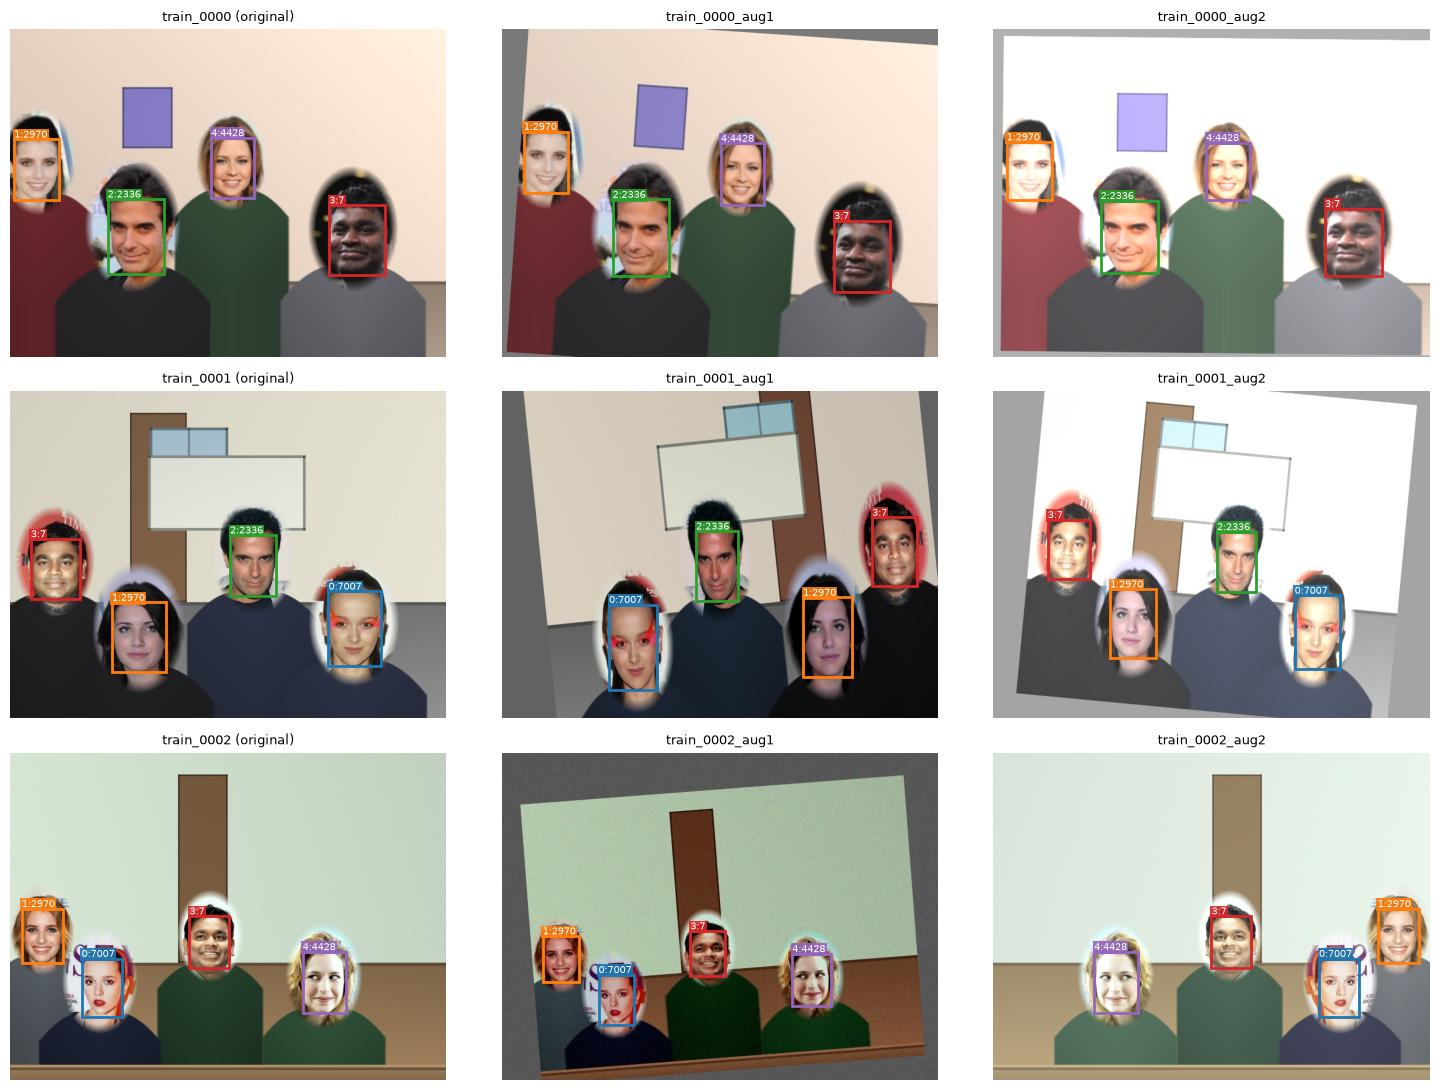

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for row, frame in zip(axes, frames["train"][:3]):
    M.draw_boxes(frame["rgb"], M.yolo_rows(frame["people"]), row[0], f"{frame['name']} (original)")
    previous = []
    for copy, ax in zip((1, 2), row[1:]):
        image, rows, _ = M.augment_frame(frame, copy, previous)
        previous.append(image)
        M.draw_boxes(image, rows, ax, f"{frame['name']}_aug{copy}")
plt.tight_layout(); plt.show()

## 5. Export: train / val / test folders and `data.yaml`

Proportions are defined on the 240 composed frames: **70 / 15 / 15** (168 / 36 / 36). Augmented copies exist only in `train/`. Files are named `<split>_<index>.jpg` and `<split>_<index>_aug<k>.jpg`, each with a matching `.txt` label.

```
project_milestone02/dataset/
├── data.yaml            # YOLOv8 config (paths relative to this file)
├── manifest.csv         # one row per labelled face: split, image, identity, source photo, box, seed
├── source_split.csv     # which CelebA photo belongs to which split
├── summary.json         # counts and check results
├── train/ images/ labels/
├── val/   images/ labels/
└── test/  images/ labels/
```

In [8]:
manifest = M.export(frames, sources, detector)
summary = M.validate()
summary["regenerated"] = {s: dict(a) for s, a in attempts.items()}
(M.OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")

counts = pd.DataFrame({s: {"composed frames": v["composed"], "augmented copies": v["augmented"], "images": v["images"],
                           "faces": v["faces"], **{f"faces {i}": v["faces_per_identity"][i] for i in M.IDS}}
                       for s, v in summary["splits"].items()})
display(counts)
print("Composed-frame proportions:", summary["composed_proportions"], "| dataset size:", summary["dataset_mb"], "MB")
print((M.OUT_DIR / "data.yaml").read_text())

augmentation resampled 60 times (a face left the frame, a bystander face appeared, or the copy was unchanged)


,train,val,test
composed frames,168,36,36
augmented copies,336,0,0
images,504,36,36
faces,1596,111,113
faces 7007,321,21,24
faces 2970,348,26,23
faces 2336,318,20,24
faces 7,306,24,23
faces 4428,303,20,19


Composed-frame proportions: {'train': 0.7, 'val': 0.15, 'test': 0.15} | dataset size: 32.6 MB
# YOLOv8 dataset config. Paths are relative to this file's folder.
train: train/images
val: val/images
test: test/images
nc: 5
names:
  0: '7007'
  1: '2970'
  2: '2336'
  3: '7'
  4: '4428'



## 6. Checks

`M.validate()` re-reads the exported files and asserts:

- every image has a label file;
- every row has 5 values, a valid class id and a box inside the image;
- every identity appears in every split;
- no two image files are identical;
- **no source photo is used by more than one split**, and each split uses only its own photos.

The cell below re-runs YuNet on every **saved** image and compares each label with the nearest detection (confidence ≥ 0.50). For composed frames, the labels are YuNet boxes on these same pixels, so IoU = 1.0 by construction; this only confirms the files were written correctly. **For augmented images, it is an independent check** that the transformed boxes still fit the faces. Any detection that overlaps no label is counted as an unlabelled face.

In [9]:
print("Source photos used per split:", summary["source_photos_used"],
      "| shared between splits:", summary["source_photos_shared_between_splits"],
      "| duplicate images:", summary["duplicate_images"])

quality = []
for split in M.SPLITS:
    for img in sorted((M.OUT_DIR / split / "images").glob("*.jpg")):
        rgb = np.asarray(Image.open(img).convert("RGB"))
        detections = M.detect_faces(detector, rgb, M.BYSTANDER_SCORE)
        labels = M.read_label(M.OUT_DIR / split / "labels" / f"{img.stem}.txt")
        boxes = [((x - w / 2) * M.W, (y - h / 2) * M.H, (x + w / 2) * M.W, (y + h / 2) * M.H) for _, x, y, w, h in labels]
        for b in boxes:
            quality.append({"kind": "augmented" if "_aug" in img.stem else "composed",
                            "iou": max((M.iou(b, d[:4]) for d in detections), default=0.0)})
        unlabelled = sum(max((M.iou(d[:4], b) for b in boxes), default=0.0) < M.EXTRA_FACE_IOU for d in detections)
        quality.append({"kind": "unlabelled detections", "iou": np.nan, "count": unlabelled})
q = pd.DataFrame(quality)
table = q[q.kind != "unlabelled detections"].groupby("kind").iou.describe(percentiles=[0.05, 0.5])[["count", "5%", "50%", "min"]]
display(table.round(3))
print("Labels with IoU < 0.5 to any detection:", int((q.iou < 0.5).sum()),
      "| unlabelled face-like detections (confidence >= 0.5):", int(q["count"].fillna(0).sum()))

Source photos used per split: {'train': 85, 'val': 19, 'test': 17} | shared between splits: 0 | duplicate images: 0


,count,5%,50%,min
kind,,,,
augmented,1064.0,0.857,0.923,0.767
composed,756.0,1.000,1.000,1.000


Labels with IoU < 0.5 to any detection: 0 | unlabelled face-like detections (confidence >= 0.5): 0


## Sample annotated images from each split

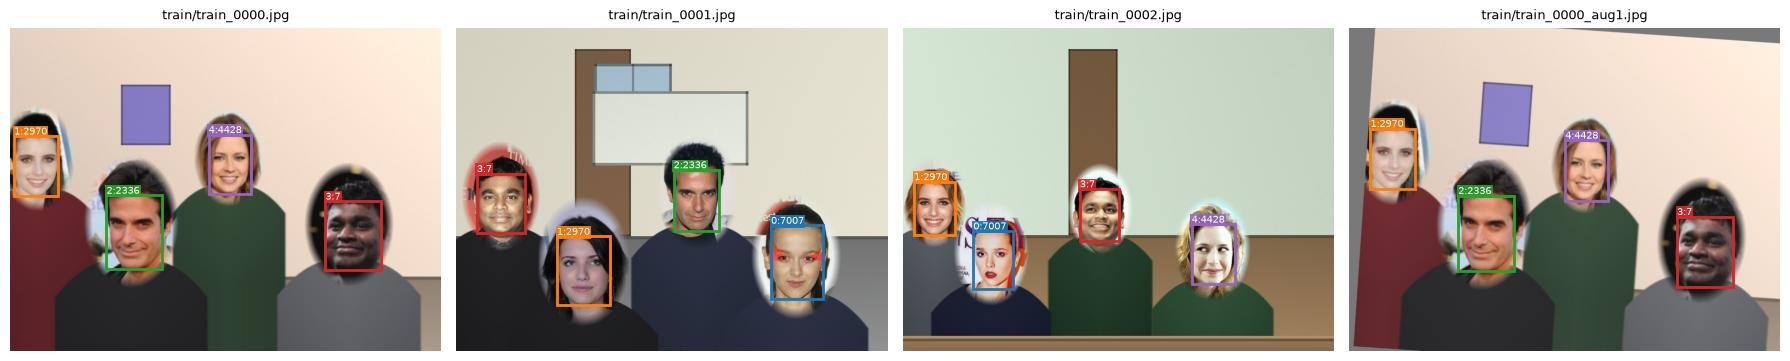

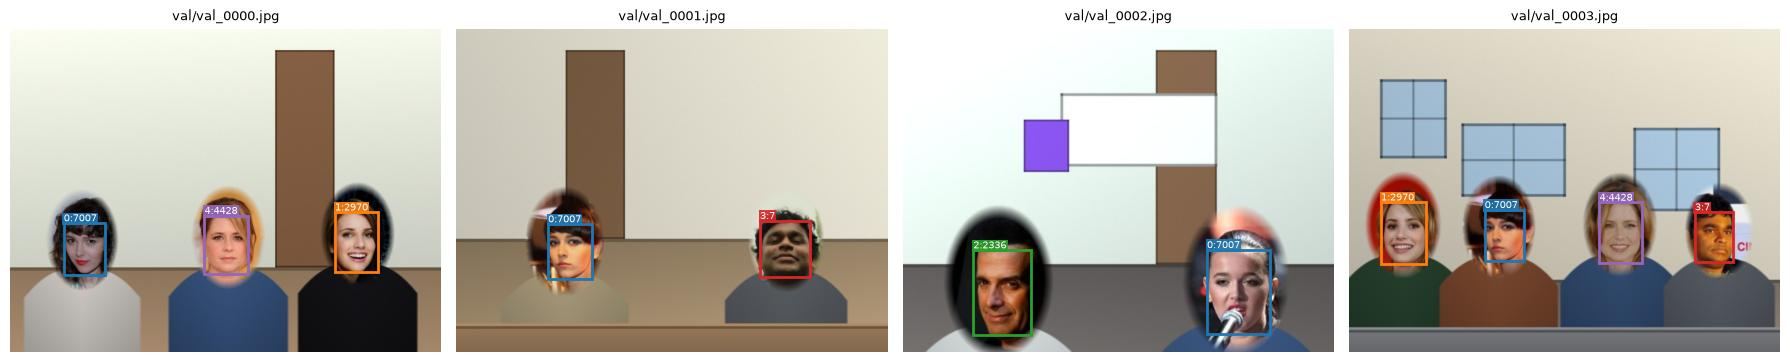

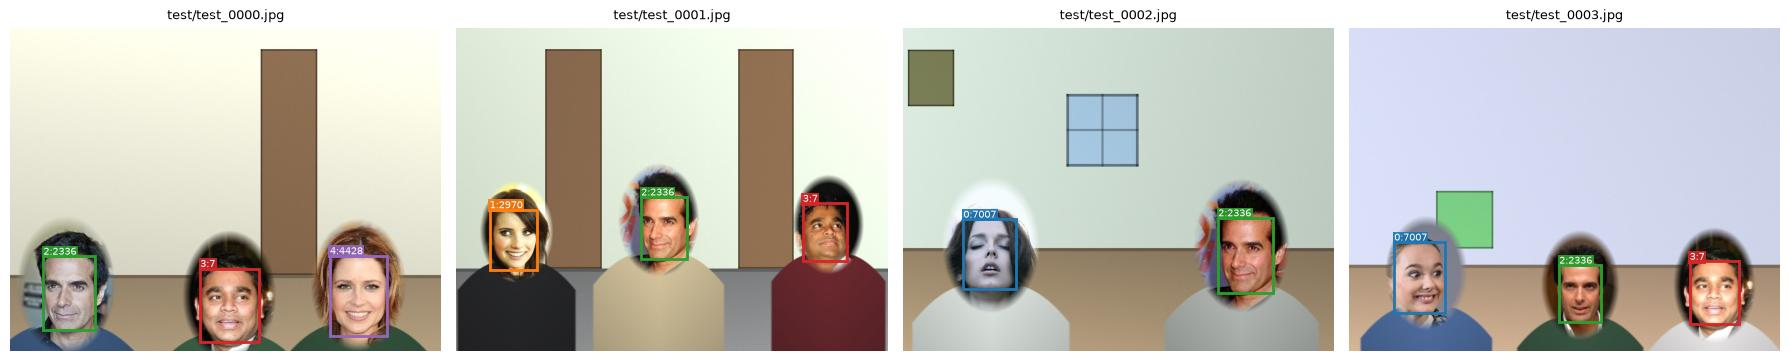

In [10]:
for split in M.SPLITS:
    images = sorted((M.OUT_DIR / split / "images").glob("*.jpg"))
    picks = [p for p in images if "_aug" not in p.stem][:3] + ([p for p in images if "_aug" in p.stem][:1] if split == "train" else [images[3]])
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
    for ax, img in zip(axes, picks):
        M.draw_boxes(np.asarray(Image.open(img).convert("RGB")), M.read_label(M.OUT_DIR / split / "labels" / f"{img.stem}.txt"), ax, f"{split}/{img.name}")
    plt.tight_layout(); plt.show()

## Hand-off to Milestone 3

The dataset is ready for YOLOv8 as-is. Ultralytics 8.4 has been checked to read `data.yaml` (504 / 36 / 36 images, 0 corrupt, 5 classes), and a 1-epoch smoke run trained and evaluated without errors. For example, from the repository root:

```sh
yolo detect train data=project_milestone02/dataset/data.yaml model=yolov8n.pt imgsz=640 epochs=100
yolo detect val   data=project_milestone02/dataset/data.yaml model=runs/detect/train/weights/best.pt split=test
```

**Notes and limitations**

- YOLOv8 also applies its own online augmentation during training (mosaic, HSV, flips, scaling). Our offline augmentation adds lighting, blur, noise, compression and small-rotation variety that YOLOv8's defaults cover only partly. To avoid stacking two strong geometric pipelines, Milestone 3 can lower `degrees`/`scale` or compare runs with and without the `_aug` files.
- Validation and test frames are composed from only 3–4 photos per identity (Milestone 1 val/test photos), seen in new layouts, scales and lighting. This is what keeps the split leak-free; it also means test faces repeat within the test split.
- The backgrounds are procedural, and heads come from tightly cropped CelebA photos, so frames are plausible group photos but not photorealistic. Real-photo generalization should be checked in Milestone 4.